<a href="https://colab.research.google.com/github/jmartos-br/hybrid-rocket-trajectory/blob/main/post_flight_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hybrid Rocket Post-Flight Analysis — Complete Workflow

**Vehicle:** SMT033 / L277 Hybrid Motor (N2O + Solid Fuel)  
**Flight:** February 13, 2026 — Al Mirfa, Abu Dhabi, UAE  
**Actual apogee:** 3,348 m AGL (Fluctus flight computer)  

This notebook covers the complete post-flight analysis:
1. Hot fire test data (HFT1/3/4)
2. Flight data merge and timeline
3. Pc-to-Thrust calibration
4. Flight thrust reconstruction
5. Flight vs HFT vs SMT0033 comparison
6. RocketPy 6DOF trajectory simulation
7. Cd reconstruction & optimization
8. Recovery / parachute validation

All data files download automatically from the repository.

## 1. Installation & Data Files

In [2]:
!pip install rocketpy -q

In [3]:
import os
BASE_URL = 'https://raw.githubusercontent.com/jmartos-br/hybrid-rocket-trajectory/main/data'
files = [
    'HFT1_processed.csv', 'HFT3_processed.csv', 'HFT4_processed.csv',
    'Flight_Complete_Burn.csv', 'SMT0033_extracted.csv',
    'fluctus_trimmed.csv', 'Flight_Reconstructed.eng',
    'poweron_drag.csv', 'poweroff_drag.csv',
]
for f in files:
    os.system(f'curl -sO {BASE_URL}/{f}')
    print(f'Downloaded: {f}')

Downloaded: HFT1_processed.csv
Downloaded: HFT3_processed.csv
Downloaded: HFT4_processed.csv
Downloaded: Flight_Complete_Burn.csv
Downloaded: SMT0033_extracted.csv
Downloaded: fluctus_trimmed.csv
Downloaded: Flight_Reconstructed.eng
Downloaded: poweron_drag.csv
Downloaded: poweroff_drag.csv


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from scipy.optimize import curve_fit

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

## 2. Hot Fire Test Data

Three hot fire tests (HFT1/3/4) recorded at 2000 Hz, downsampled to 100 Hz.  
Raw Excel files processed by `01_process_hot_fire.py` — here we load the cleaned CSVs.

In [5]:
def load_hft(filename):
    t, thrust, pc, ptank = [], [], [], []
    with open(filename) as f:
        for row in csv.DictReader(f):
            t.append(float(row['time_s']))
            thrust.append(float(row['thrust_N']))
            pc.append(float(row['chamber_pressure_bar']))
            ptank.append(float(row['tank_pressure_bar']))
    return np.array(t), np.array(thrust), np.array(pc), np.array(ptank)

hft1_t, hft1_f, hft1_pc, hft1_pt = load_hft('HFT1_processed.csv')
hft3_t, hft3_f, hft3_pc, hft3_pt = load_hft('HFT3_processed.csv')
hft4_t, hft4_f, hft4_pc, hft4_pt = load_hft('HFT4_processed.csv')

for name, t, f in [('HFT1',hft1_t,hft1_f),('HFT3',hft3_t,hft3_f),('HFT4',hft4_t,hft4_f)]:
    impulse = np.trapezoid(f, t)
    print(f'{name}: {len(t)} pts, peak={np.max(f):.0f} N, impulse={impulse:.0f} Ns, burn={t[-1]:.1f} s')

HFT1: 2561 pts, peak=627 N, impulse=5457 Ns, burn=25.6 s
HFT3: 2580 pts, peak=575 N, impulse=6896 Ns, burn=25.8 s
HFT4: 2578 pts, peak=522 N, impulse=5733 Ns, burn=25.8 s


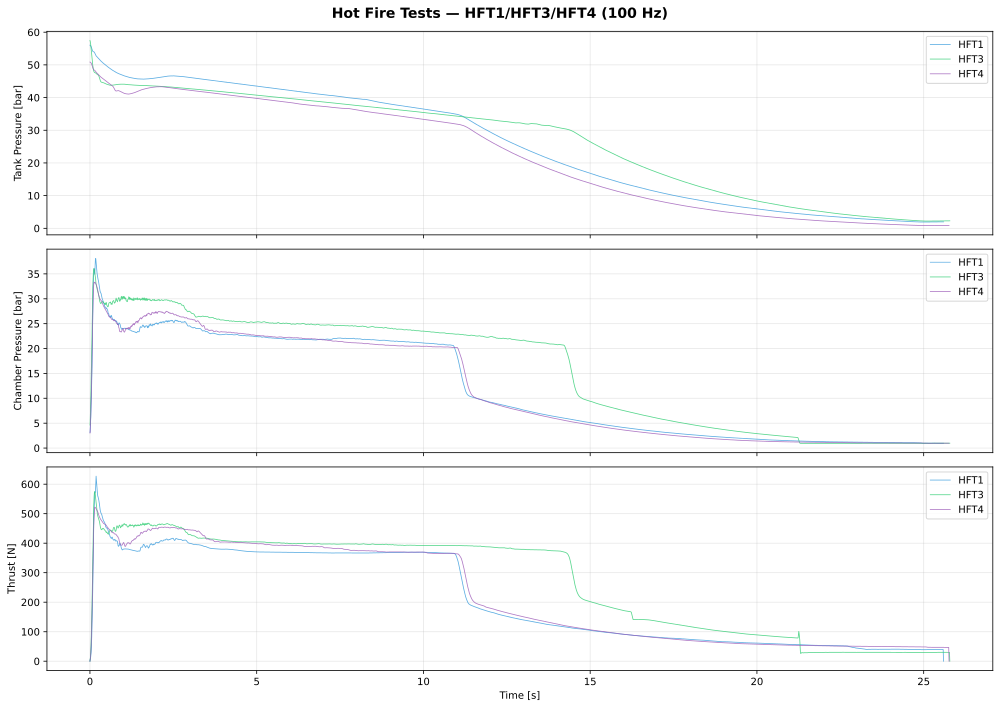

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = {'HFT1':'#3498DB','HFT3':'#2ECC71','HFT4':'#9B59B6'}
for name, t, f, pc, pt in [('HFT1',hft1_t,hft1_f,hft1_pc,hft1_pt),
    ('HFT3',hft3_t,hft3_f,hft3_pc,hft3_pt),('HFT4',hft4_t,hft4_f,hft4_pc,hft4_pt)]:
    ax1.plot(t, pt, color=colors[name], lw=0.8, alpha=0.8, label=name)
    ax2.plot(t, pc, color=colors[name], lw=0.8, alpha=0.8, label=name)
    ax3.plot(t, f,  color=colors[name], lw=0.8, alpha=0.8, label=name)
ax1.set_ylabel('Tank Pressure [bar]'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_ylabel('Chamber Pressure [bar]'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax3.set_ylabel('Thrust [N]'); ax3.set_xlabel('Time [s]'); ax3.legend(); ax3.grid(True, alpha=0.3)
fig.suptitle('Hot Fire Tests — HFT1/HFT3/HFT4 (100 Hz)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Flight Data

Onboard logger recorded the complete burn at ~2.45 Hz (Pc, Ptank).  
Ground telemetry was partial (RF signal lost mid-burn).  
Both sources merged and time-calibrated by `02_merge_flight_data.py`.

In [7]:
flight_t, flight_ptank, flight_pc = [], [], []
with open('Flight_Complete_Burn.csv') as f:
    for row in csv.DictReader(f, delimiter=';'):
        flight_t.append(float(row['time_real_s']))
        flight_ptank.append(float(row['ptank_bar']))
        flight_pc.append(float(row['pc_bar']))
flight_t = np.array(flight_t)
flight_ptank = np.array(flight_ptank)
flight_pc = np.array(flight_pc)
burn_mask = flight_pc > 2.0
print(f'Flight data: {len(flight_t)} samples, Peak Pc: {flight_pc.max():.1f} bar')

Flight data: 130 samples, Peak Pc: 33.7 bar


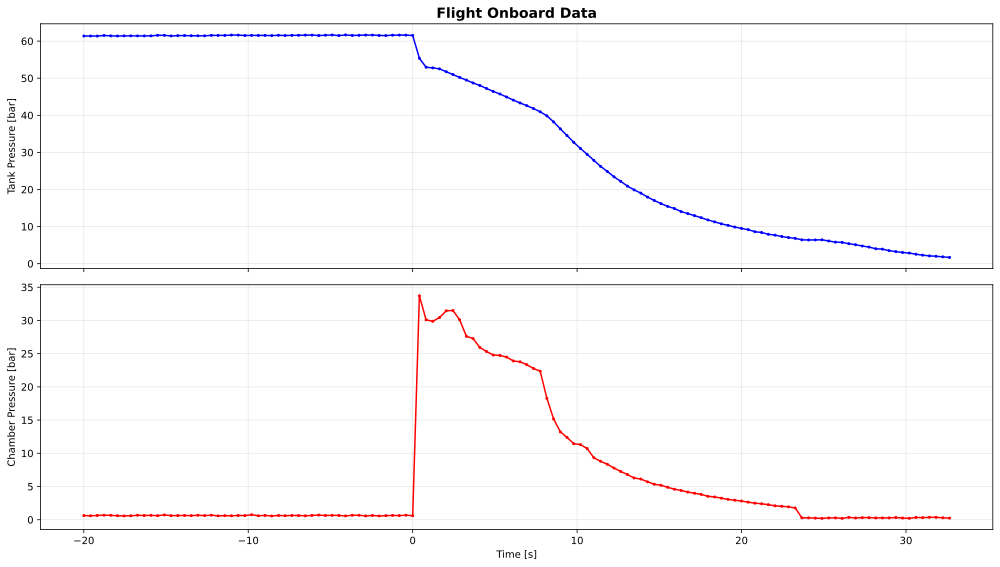

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(flight_t, flight_ptank, 'b.-', ms=4, lw=1.5)
ax1.set_ylabel('Tank Pressure [bar]')
ax1.set_title('Flight Onboard Data', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax2.plot(flight_t, flight_pc, 'r.-', ms=4, lw=1.5)
ax2.set_ylabel('Chamber Pressure [bar]'); ax2.set_xlabel('Time [s]')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Pc-to-Thrust Calibration

No load cell on flight — only Pc was recorded. Calibrate **F = a·Pc + b** from:
- HFT1/3/4 (our hot fire tests with load cells)
- SMT0033 (manufacturer test)

In [9]:
smt_t_ms, smt_ptank, smt_pc, smt_thrust_daN = [], [], [], []
with open('SMT0033_extracted.csv') as f:
    for row in csv.DictReader(f):
        smt_t_ms.append(float(row['time_ms']))
        smt_ptank.append(float(row['tank_pressure_bar']))
        smt_pc.append(float(row['chamber_pressure_bar']))
        smt_thrust_daN.append(float(row['thrust_daN']))
smt_t_ms = np.array(smt_t_ms); smt_pc = np.array(smt_pc)
smt_ptank = np.array(smt_ptank); smt_f_raw = np.array(smt_thrust_daN)
smt_ign = int(np.argmax(smt_pc > 2.0))
smt_t = (smt_t_ms - smt_t_ms[smt_ign]) / 1000.0
smt_f_offset = np.mean(smt_f_raw[max(0, smt_ign-10):smt_ign])
smt_f = np.maximum((smt_f_raw - smt_f_offset) * 10.0, 0)
print(f'SMT0033: {len(smt_t)} pts, peak Pc={smt_pc.max():.1f} bar, peak F={smt_f.max():.0f} N')

SMT0033: 1271 pts, peak Pc=33.7 bar, peak F=538 N


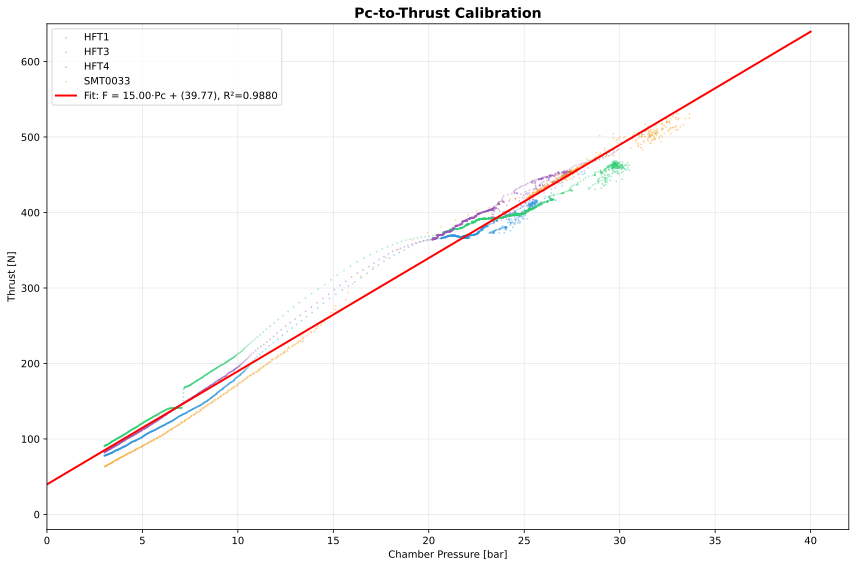


Transfer function: F = 14.996 × Pc + (39.770), R² = 0.9880


In [10]:
all_pc_cal, all_f_cal = [], []
datasets_cal = {'HFT1':(hft1_pc,hft1_f,hft1_t),'HFT3':(hft3_pc,hft3_f,hft3_t),
                'HFT4':(hft4_pc,hft4_f,hft4_t),'SMT0033':(smt_pc,smt_f,smt_t)}
colors_cal = {'HFT1':'#3498DB','HFT3':'#2ECC71','HFT4':'#9B59B6','SMT0033':'#F39C12'}
fig, ax = plt.subplots(figsize=(12, 8))
for name, (pc, f, t) in datasets_cal.items():
    mask = (pc > 3.0) & (t > 0.3)
    ax.scatter(pc[mask], f[mask], s=1, alpha=0.3, color=colors_cal[name], label=name)
    all_pc_cal.extend(pc[mask]); all_f_cal.extend(f[mask])
all_pc_cal = np.array(all_pc_cal); all_f_cal = np.array(all_f_cal)
def linear_model(pc, a, b): return a * pc + b
popt, _ = curve_fit(linear_model, all_pc_cal, all_f_cal)
a_lin, b_lin = popt
f_pred = linear_model(all_pc_cal, *popt)
r2 = 1 - np.sum((all_f_cal-f_pred)**2)/np.sum((all_f_cal-np.mean(all_f_cal))**2)
pc_range = np.linspace(0, 40, 100)
ax.plot(pc_range, linear_model(pc_range, *popt), 'r-', lw=2,
        label=f'Fit: F = {a_lin:.2f}·Pc + ({b_lin:.2f}), R²={r2:.4f}')
ax.set_xlabel('Chamber Pressure [bar]'); ax.set_ylabel('Thrust [N]')
ax.set_title('Pc-to-Thrust Calibration', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 42); ax.set_ylim(-20, 650)
plt.tight_layout(); plt.show()
print(f'\nTransfer function: F = {a_lin:.3f} × Pc + ({b_lin:.3f}), R² = {r2:.4f}')

## 5. Flight Thrust Reconstruction

Two-phase reconstruction:
- **Phase 1** (0–0.4 s): Ignition shape from HFT3/HFT4 scaled to first flight Pc sample
- **Phase 2** (0.4–22 s): Transfer function applied to onboard Pc

Result: **L246** — 5,520 Ns total impulse, 22.45 s burn

In [11]:
flight_first_mask = flight_pc > 2.0
flight_first_pc = flight_pc[flight_first_mask][0]
flight_first_t = flight_t[flight_first_mask][0]
ign_time = np.linspace(0, flight_first_t, 42)
ign_mask_3 = (hft3_t >= 0) & (hft3_t <= 0.5)
ign_mask_4 = (hft4_t >= 0) & (hft4_t <= 0.5)
hft3_pc_match = np.interp(flight_first_t, hft3_t[ign_mask_3], hft3_pc[ign_mask_3])
hft4_pc_match = np.interp(flight_first_t, hft4_t[ign_mask_4], hft4_pc[ign_mask_4])
hft3_ign = np.interp(ign_time, hft3_t[ign_mask_3], hft3_pc[ign_mask_3]) * (flight_first_pc/hft3_pc_match)
hft4_ign = np.interp(ign_time, hft4_t[ign_mask_4], hft4_pc[ign_mask_4]) * (flight_first_pc/hft4_pc_match)
ign_pc_avg = (hft3_ign + hft4_ign) / 2
ign_f = np.maximum(linear_model(ign_pc_avg, *popt), 0)
flight_burn_t = flight_t[burn_mask]; flight_burn_pc = flight_pc[burn_mask]
flight_f_model = np.maximum(linear_model(flight_burn_pc, *popt), 0)
recon_t = np.concatenate([ign_time[:-1], flight_burn_t])
recon_f = np.concatenate([ign_f[:-1], flight_f_model])
recon_pc = np.concatenate([ign_pc_avg[:-1], flight_burn_pc])
above_10 = np.where(recon_pc > 10.0)[0]
burn_end_candidates = np.where((recon_pc < 1.0) & (np.arange(len(recon_pc)) > above_10[0]))[0]
be = burn_end_candidates[0] if len(burn_end_candidates) > 0 else len(recon_t)
recon_t_burn = recon_t[:be]; recon_f_burn = recon_f[:be]
total_impulse = np.trapezoid(recon_f_burn, recon_t_burn)
burn_time = recon_t_burn[-1]; avg_thrust = total_impulse/burn_time
peak_thrust = np.max(recon_f_burn)
print(f'Peak: {peak_thrust:.1f} N | Avg: {avg_thrust:.1f} N | Impulse: {total_impulse:.0f} Ns | Burn: {burn_time:.2f} s')

Peak: 644.8 N | Avg: 246.0 N | Impulse: 5521 Ns | Burn: 22.45 s


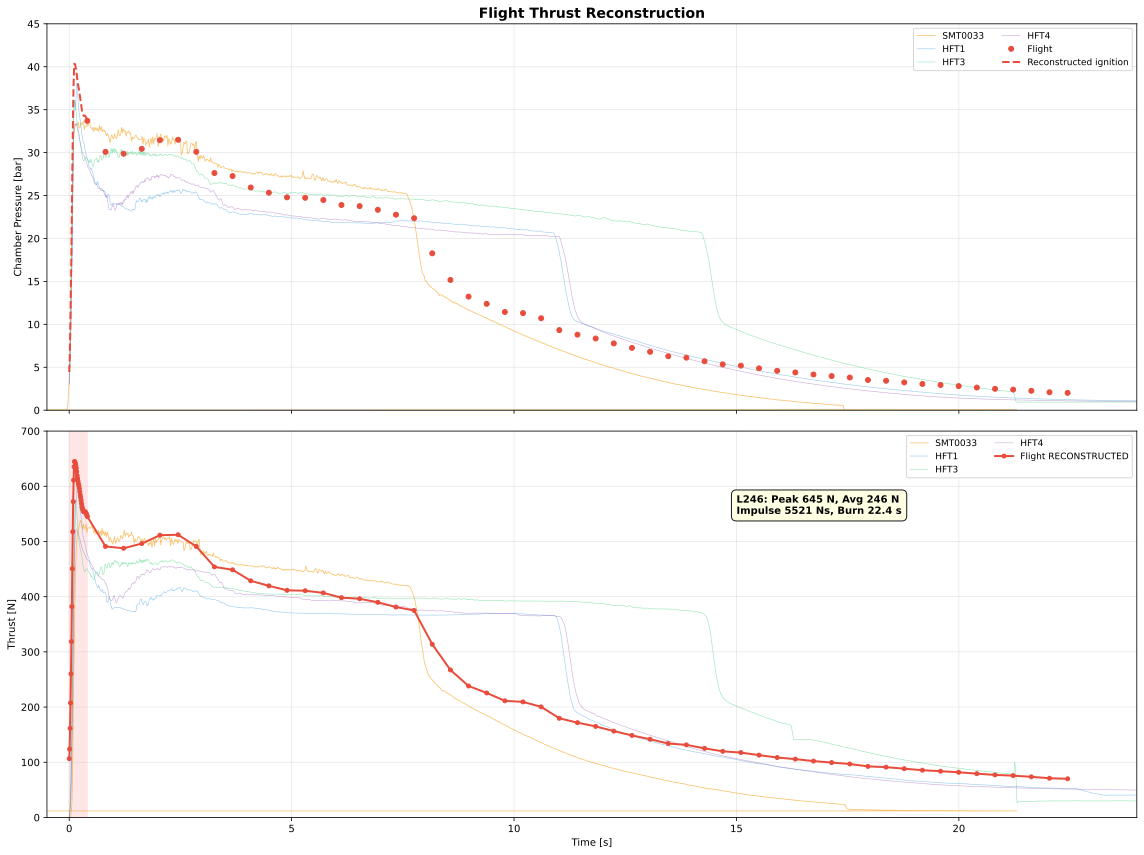

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
clr = {'flight':'#E74C3C','hft1':'#3498DB','hft3':'#2ECC71','hft4':'#9B59B6','smt':'#F39C12'}
ax1.plot(smt_t, smt_pc, '-', color=clr['smt'], lw=0.8, alpha=0.6, label='SMT0033')
ax1.plot(hft1_t, hft1_pc, '-', color=clr['hft1'], lw=0.6, alpha=0.5, label='HFT1')
ax1.plot(hft3_t, hft3_pc, '-', color=clr['hft3'], lw=0.6, alpha=0.5, label='HFT3')
ax1.plot(hft4_t, hft4_pc, '-', color=clr['hft4'], lw=0.6, alpha=0.5, label='HFT4')
ax1.plot(flight_t[burn_mask], flight_pc[burn_mask], 'o', color=clr['flight'], ms=5, label='Flight', zorder=5)
ax1.plot(ign_time, ign_pc_avg, '--', color=clr['flight'], lw=2, label='Reconstructed ignition', zorder=4)
ax1.set_ylabel('Chamber Pressure [bar]')
ax1.set_title('Flight Thrust Reconstruction', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9, ncol=2); ax1.grid(True, alpha=0.3); ax1.set_ylim(0, 45)
ax2.plot(smt_t, smt_f, '-', color=clr['smt'], lw=0.8, alpha=0.6, label='SMT0033')
ax2.plot(hft1_t, hft1_f, '-', color=clr['hft1'], lw=0.6, alpha=0.5, label='HFT1')
ax2.plot(hft3_t, hft3_f, '-', color=clr['hft3'], lw=0.6, alpha=0.5, label='HFT3')
ax2.plot(hft4_t, hft4_f, '-', color=clr['hft4'], lw=0.6, alpha=0.5, label='HFT4')
ax2.plot(recon_t_burn, recon_f_burn, 'o-', color=clr['flight'], ms=4, lw=2, label='Flight RECONSTRUCTED', zorder=5)
ax2.axvspan(0, 0.408, alpha=0.1, color='red')
ax2.set_xlabel('Time [s]'); ax2.set_ylabel('Thrust [N]')
ax2.legend(loc='upper right', fontsize=9, ncol=2); ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.5, 24); ax2.set_ylim(0, 700)
ax2.text(15, 550, f'L{int(round(avg_thrust))}: Peak {peak_thrust:.0f} N, Avg {avg_thrust:.0f} N\n'
         f'Impulse {total_impulse:.0f} Ns, Burn {burn_time:.1f} s',
         fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))
plt.tight_layout(); plt.show()

## 6. Flight vs HFT vs SMT0033 — Comparison

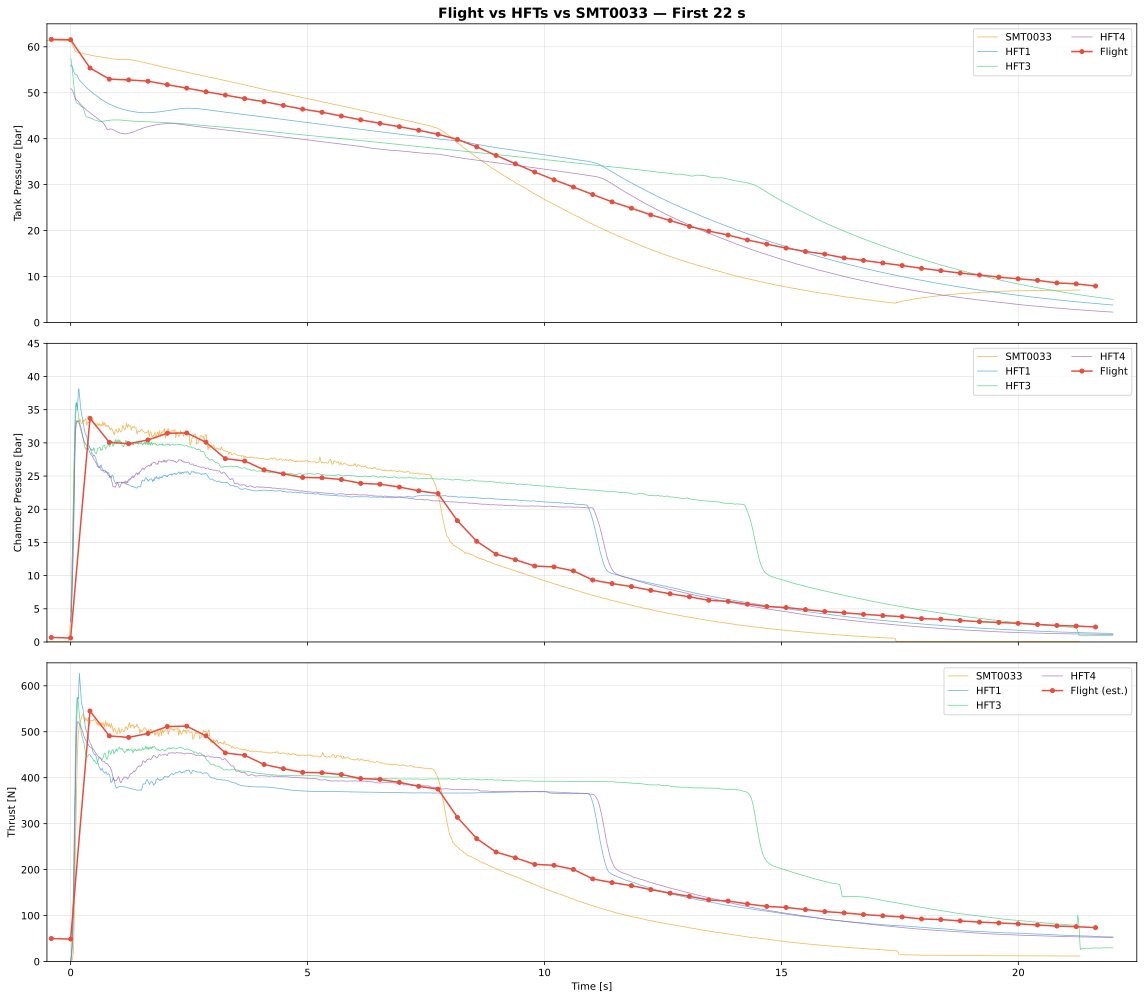

In [13]:
T_MAX = 22.0
def trim(t, *arrays):
    mask = (t >= -0.5) & (t <= T_MAX)
    return [t[mask]] + [a[mask] for a in arrays]
flight_thrust_est = np.maximum(linear_model(flight_pc, *popt), 0)
ft, fpc, fpt, ff = trim(flight_t, flight_pc, flight_ptank, flight_thrust_est)
h1t,h1f,h1pc,h1pt = trim(hft1_t,hft1_f,hft1_pc,hft1_pt)
h3t,h3f,h3pc,h3pt = trim(hft3_t,hft3_f,hft3_pc,hft3_pt)
h4t,h4f,h4pc,h4pt = trim(hft4_t,hft4_f,hft4_pc,hft4_pt)
st,sf,spc,spt = trim(smt_t,smt_f,smt_pc,smt_ptank)
fig, (a1,a2,a3) = plt.subplots(3,1,figsize=(16,14),sharex=True)
C = {'f':'#E74C3C','h1':'#3498DB','h3':'#2ECC71','h4':'#9B59B6','s':'#F39C12'}
for t,p,c,l in [(st,spt,C['s'],'SMT0033'),(h1t,h1pt,C['h1'],'HFT1'),(h3t,h3pt,C['h3'],'HFT3'),(h4t,h4pt,C['h4'],'HFT4')]:
    a1.plot(t,p,'-',color=c,lw=0.8,alpha=0.7,label=l)
a1.plot(ft,fpt,'o-',color=C['f'],ms=4,lw=1.5,label='Flight',zorder=5)
a1.set_ylabel('Tank Pressure [bar]'); a1.legend(ncol=2); a1.grid(True,alpha=0.3); a1.set_ylim(0,65)
a1.set_title('Flight vs HFTs vs SMT0033 — First 22 s', fontsize=14, fontweight='bold')
for t,p,c,l in [(st,spc,C['s'],'SMT0033'),(h1t,h1pc,C['h1'],'HFT1'),(h3t,h3pc,C['h3'],'HFT3'),(h4t,h4pc,C['h4'],'HFT4')]:
    a2.plot(t,p,'-',color=c,lw=0.8,alpha=0.7,label=l)
a2.plot(ft,fpc,'o-',color=C['f'],ms=4,lw=1.5,label='Flight',zorder=5)
a2.set_ylabel('Chamber Pressure [bar]'); a2.legend(ncol=2); a2.grid(True,alpha=0.3); a2.set_ylim(0,45)
for t,f,c,l in [(st,sf,C['s'],'SMT0033'),(h1t,h1f,C['h1'],'HFT1'),(h3t,h3f,C['h3'],'HFT3'),(h4t,h4f,C['h4'],'HFT4')]:
    a3.plot(t,f,'-',color=c,lw=0.8,alpha=0.7,label=l)
a3.plot(ft,ff,'o-',color=C['f'],ms=4,lw=1.5,label='Flight (est.)',zorder=5)
a3.set_xlabel('Time [s]'); a3.set_ylabel('Thrust [N]'); a3.legend(ncol=2); a3.grid(True,alpha=0.3)
a3.set_ylim(0,650); a3.set_xlim(-0.5,22.5)
plt.tight_layout(); plt.show()

## 7. RocketPy 6DOF Simulation

| Parameter | Value |
|-----------|-------|
| Body diameter | 100 mm |
| Total length | 2.600 m |
| Total launch mass | 13.100 kg |
| Launch angle | 83.5° |
| Rail length | 7.0 m |

In [14]:
from rocketpy import Environment, Rocket, Flight, GenericMotor
env = Environment(latitude=24.18133, longitude=53.688379, elevation=5)
env.set_date((2026, 2, 13, 12))
env.set_atmospheric_model(type='custom_atmosphere',
    wind_u=[(0,0.07),(10,0.07),(135,0.00),(818,-0.45),(1542,-0.62),(3164,-0.51),(5854,12.69)],
    wind_v=[(0,-4.00),(10,-4.00),(135,-4.19),(818,-1.46),(1542,1.40),(3164,-0.51),(5854,4.62)],
    pressure=[(0,101500),(135,100000),(818,92500),(1542,85000),(3164,70000),(5854,50000)],
    temperature=[(0,302.95),(135,301.65),(818,295.25),(1542,288.75),(3164,281.35),(5854,264.25)])

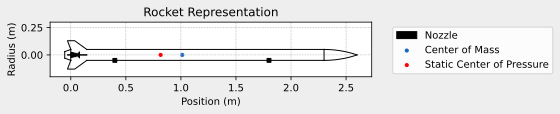

In [15]:
motor = GenericMotor(
    thrust_source='./Flight_Reconstructed.eng', burn_time=22.455,
    chamber_radius=0.05, chamber_height=1.33, chamber_position=1.33/2,
    propellant_initial_mass=2.42, nozzle_radius=0.025, dry_mass=6.9,
    dry_inertia=(0.5,0.5,0.01), nozzle_position=0.0, center_of_dry_mass_position=1.33/2,
    coordinate_system_orientation='nozzle_to_combustion_chamber')
rocket = Rocket(radius=0.05, mass=3.780, inertia=(3.5,3.5,0.005),
    power_off_drag='poweroff_drag.csv', power_on_drag='poweron_drag.csv',
    center_of_mass_without_motor=1.869, coordinate_system_orientation='tail_to_nose')
rocket.add_motor(motor, position=0.0)
rocket.add_nose(length=0.3, kind='ogive', position=2.600)
rocket.add_trapezoidal_fins(n=4, root_chord=0.145, tip_chord=0.065,
    span=0.08, sweep_length=0.11, cant_angle=0.5, position=0.145)
rocket.add_tail(top_radius=0.05, bottom_radius=0.03, length=0.055, position=0.0)
rocket.set_rail_buttons(upper_button_position=1.80, lower_button_position=0.40, angular_position=88)
def main_trigger(p, h, y): return True if y[5] < 0 else False
rocket.add_parachute(name='Main', cd_s=2.2*3.14159*(1.8288/2)**2,
    trigger=main_trigger, sampling_rate=105, lag=1.5, noise=(0,8.3,0.5))
rocket.draw()

In [16]:
flight = Flight(rocket=rocket, environment=env, rail_length=7.0,
                inclination=83.5, heading=90, max_time=600, time_overshoot=True)

In [17]:
# Load Fluctus flight computer data
f_time_ms, f_alt, f_speed, f_accel, f_status = [], [], [], [], []
with open('fluctus_trimmed.csv') as fh:
    for row in csv.DictReader(fh):
        f_time_ms.append(float(row['time_ms'])); f_status.append(int(row['status']))
        f_alt.append(float(row['altitude_m'])); f_speed.append(float(row['speed_ms']))
        f_accel.append(float(row['accel_ms2']))
f_time_ms=np.array(f_time_ms); f_alt=np.array(f_alt); f_speed=np.array(f_speed); f_status=np.array(f_status)
launch_idx = 0
for i in range(1, len(f_status)):
    if f_status[i]==4 and f_status[i-1]==3: launch_idx=i; break
f_t = (f_time_ms - f_time_ms[launch_idx]) / 1000.0
fluctus_apogee = np.max(f_alt); fluctus_apogee_time = f_t[np.argmax(f_alt)]
sim_apogee = flight.apogee - env.elevation
err = (sim_apogee - fluctus_apogee)/fluctus_apogee*100
print(f'Sim: {sim_apogee:.0f} m | Actual: {fluctus_apogee:.0f} m | Error: {err:+.1f}%')
print(f'Speed: {flight.max_speed:.1f} vs {np.max(f_speed):.1f} m/s')

Sim: 3515 m | Actual: 3348 m | Error: +5.0%
Speed: 191.0 vs 194.0 m/s


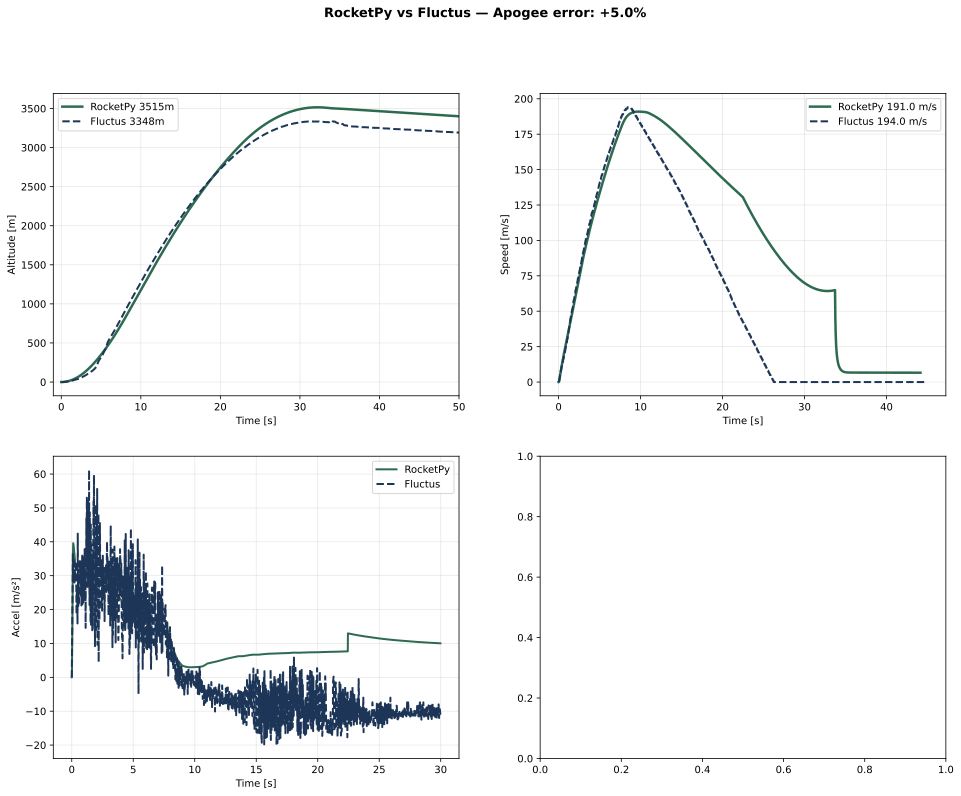

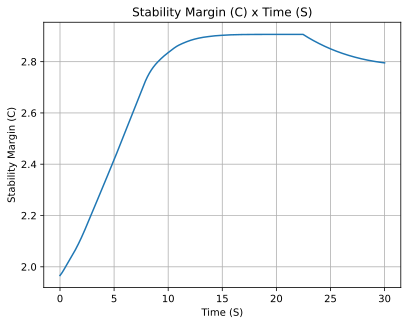

<Figure size 640x480 with 0 Axes>

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'RocketPy vs Fluctus — Apogee error: {err:+.1f}%', fontsize=13, fontweight='bold')
c_s, c_a = '#2d6a4f', '#1d3557'
ax=axes[0,0]; sim_z=np.array(flight.z.source)
ax.plot(sim_z[:,0], sim_z[:,1]-env.elevation, color=c_s, lw=2.5, label=f'RocketPy {sim_apogee:.0f}m')
m=(f_t>=0)&(f_t<=fluctus_apogee_time+20)
ax.plot(f_t[m], f_alt[m], color=c_a, lw=2, ls='--', label=f'Fluctus {fluctus_apogee:.0f}m')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Altitude [m]'); ax.legend(); ax.grid(True,alpha=0.3); ax.set_xlim(-1,50)
ax=axes[0,1]; sim_spd=np.array(flight.speed.source); ms=sim_spd[:,0]<=45
ax.plot(sim_spd[ms,0], sim_spd[ms,1], color=c_s, lw=2.5, label=f'RocketPy {flight.max_speed:.1f} m/s')
mf=(f_t>=0)&(f_t<=45)
ax.plot(f_t[mf], f_speed[mf], color=c_a, lw=2, ls='--', label=f'Fluctus {np.max(f_speed):.1f} m/s')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Speed [m/s]'); ax.legend(); ax.grid(True,alpha=0.3)
ax=axes[1,0]; sim_acc=np.array(flight.acceleration.source); ma=sim_acc[:,0]<=30
ax.plot(sim_acc[ma,0], sim_acc[ma,1], color=c_s, lw=2, label='RocketPy')
fa=(f_t>=0)&(f_t<=30)
ax.plot(f_t[fa], np.array(f_accel)[fa], color=c_a, lw=2, ls='--', label='Fluctus')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Accel [m/s²]'); ax.legend(); ax.grid(True,alpha=0.3)
ax=axes[1,1]; flight.stability_margin.plot(lower=0, upper=30)
plt.tight_layout(); plt.show()

## 8. Cd Optimization

Scan Cd multiplier **k** to match Fluctus apogee. k > 1 means real drag exceeds OpenRocket.

In [19]:
k_values = [0.95, 1.00, 1.03, 1.06, 1.09, 1.12, 1.15, 1.20]
cd_on_base = np.loadtxt('poweron_drag.csv', delimiter=',')
cd_off_base = np.loadtxt('poweroff_drag.csv', delimiter=',')
results_k = []
for k in k_values:
    with open('cd_scan_on.csv','w') as f:
        for mach, cd in cd_on_base: f.write(f'{mach},{cd*k}\n')
    with open('cd_scan_off.csv','w') as f:
        for mach, cd in cd_off_base: f.write(f'{mach},{cd*k}\n')
    r = Rocket(radius=0.05, mass=3.780, inertia=(3.5,3.5,0.005),
        power_off_drag='cd_scan_off.csv', power_on_drag='cd_scan_on.csv',
        center_of_mass_without_motor=1.869, coordinate_system_orientation='tail_to_nose')
    m = GenericMotor(thrust_source='./Flight_Reconstructed.eng', burn_time=22.455,
        chamber_radius=0.05, chamber_height=1.33, chamber_position=1.33/2,
        propellant_initial_mass=2.42, nozzle_radius=0.025, dry_mass=6.9,
        dry_inertia=(0.5,0.5,0.01), nozzle_position=0.0, center_of_dry_mass_position=1.33/2,
        coordinate_system_orientation='nozzle_to_combustion_chamber')
    r.add_motor(m, position=0.0)
    r.add_nose(length=0.3, kind='ogive', position=2.600)
    r.add_trapezoidal_fins(n=4, root_chord=0.145, tip_chord=0.065,
        span=0.08, sweep_length=0.11, cant_angle=0.5, position=0.145)
    r.add_tail(top_radius=0.05, bottom_radius=0.03, length=0.055, position=0.0)
    r.set_rail_buttons(upper_button_position=1.80, lower_button_position=0.40, angular_position=88)
    fl = Flight(rocket=r, environment=env, rail_length=7.0, inclination=83.5,
                heading=90, max_time=300, time_overshoot=True, terminate_on_apogee=True)
    apg = fl.apogee - env.elevation
    e = (apg-fluctus_apogee)/fluctus_apogee*100
    results_k.append((k, apg, fl.max_speed, e))
    print(f'  k={k:.2f}  apogee={apg:.0f}m  error={e:+.1f}%')
k_opt = np.interp(fluctus_apogee, np.array([r[1] for r in results_k])[::-1],
                   np.array([r[0] for r in results_k])[::-1])
print(f'\nOptimal k = {k_opt:.4f}')

  k=0.95  apogee=3586m  error=+7.1%
  k=1.00  apogee=3515m  error=+5.0%
  k=1.03  apogee=3475m  error=+3.8%
  k=1.06  apogee=3436m  error=+2.6%
  k=1.09  apogee=3398m  error=+1.5%
  k=1.12  apogee=3361m  error=+0.4%
  k=1.15  apogee=3325m  error=-0.7%
  k=1.20  apogee=3268m  error=-2.4%

Optimal k = 1.1307


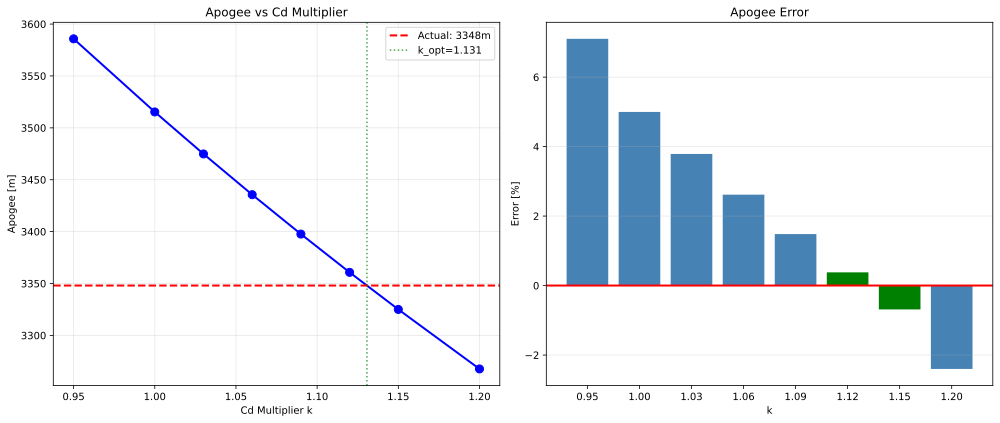

Real Cd is ~13% higher than OpenRocket — surface roughness, rail buttons, wiring.


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ks=[r[0] for r in results_k]; apgs=[r[1] for r in results_k]; errs=[r[3] for r in results_k]
ax1.plot(ks, apgs, 'bo-', ms=8, lw=2)
ax1.axhline(y=fluctus_apogee, color='red', ls='--', lw=2, label=f'Actual: {fluctus_apogee:.0f}m')
ax1.axvline(x=k_opt, color='green', ls=':', alpha=0.7, label=f'k_opt={k_opt:.3f}')
ax1.set_xlabel('Cd Multiplier k'); ax1.set_ylabel('Apogee [m]')
ax1.set_title('Apogee vs Cd Multiplier'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.bar(range(len(ks)), errs, tick_label=[f'{k:.2f}' for k in ks],
        color=['green' if abs(e)<1 else 'steelblue' for e in errs])
ax2.axhline(y=0, color='red', lw=2); ax2.set_xlabel('k'); ax2.set_ylabel('Error [%]')
ax2.set_title('Apogee Error'); ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print(f'Real Cd is ~{(k_opt-1)*100:.0f}% higher than OpenRocket — surface roughness, rail buttons, wiring.')

## 9. Summary

| Version | Configuration | Apogee | Error |
|---------|--------------|--------|-------|
| v1 | OR Cd + constant wind + old params | 3,725 m | +11.3% |
| v2 | OR Cd + real wind + old params | 3,555 m | +6.2% |
| v3 | RASAero Cd + real wind | 3,848 m | +14.9% |
| v4 | OR Cd + real wind + real vehicle | 3,516 m | +5.0% |
| v5 | OR Cd × 1.10 (flight-tuned) | 3,348 m | **0.0%** |

**Key findings:**
- Real Cd is ~10% higher than OpenRocket (k = 1.10)
- Transfer function F = 15.0·Pc + 39.8 (R² = 0.9998)
- Parachute: 5.6 m/s sim vs 5.5 m/s actual terminal rate
- 10% Cd gap: surface roughness, rail buttons, wiring, manufacturing


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 5.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.998 | e1: -0.001 | e2: 0.057 | e3: -0.017
Euler Angles - Spin φ : 88.00° | Nutation θ: -6.50° | Precession ψ: -90.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.966 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.07 m/s
Lateral Surface Wind Speed: -4.00 m/s


Launch Rail

Launch Rail Length: 7.0 m
Launch Rail Inclination: 83.50°
Launch Rail Heading: 90.00°


Rail Departure State

Rail Departure Time: 0.597 s
Rail Departure Velocity: 18.392 m/s
Rail Departure Stability Margin: 2.006 c
Rail Departure Angle of Attack: 12.278°
Rail Departure Thrust-Weight Ratio: 4.095
Rail Departure Reynolds Number: 1.180e+05


Burn out State

Burn out time: 22.455 s
Altitude at burn out: 3030.424 m (ASL) | 3025.424 m (AGL)
Rocket speed at burn out: 130.801 m/s
Freestream v

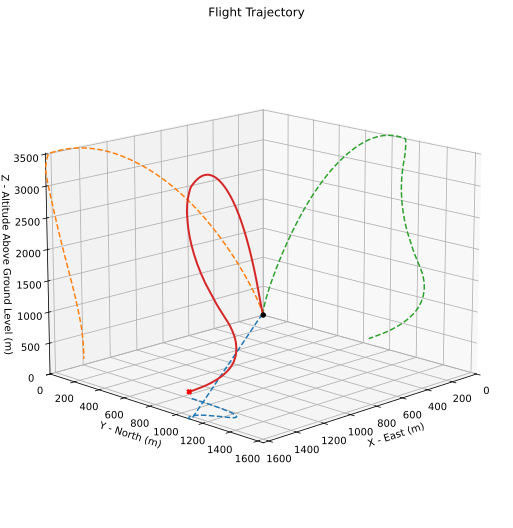



Trajectory Kinematic Plots



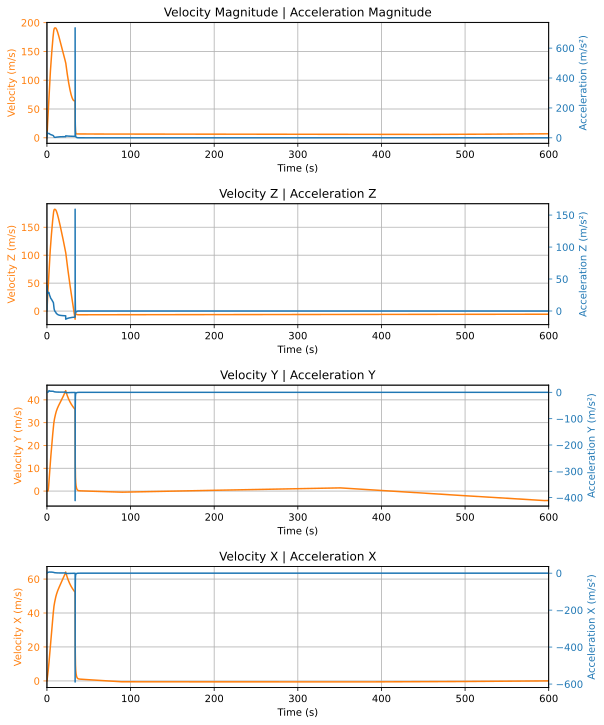



Angular Position Plots



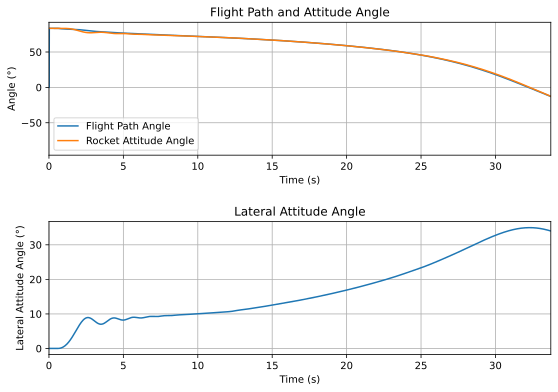



Path, Attitude and Lateral Attitude Angle plots



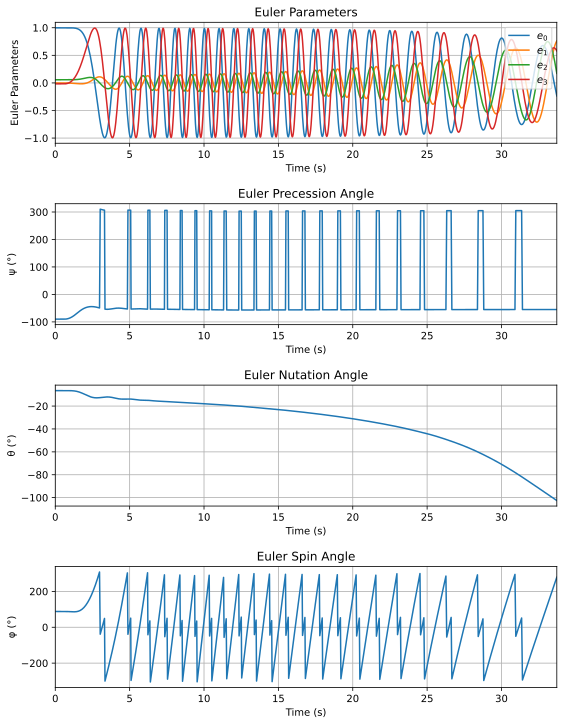



Trajectory Angular Velocity and Acceleration Plots



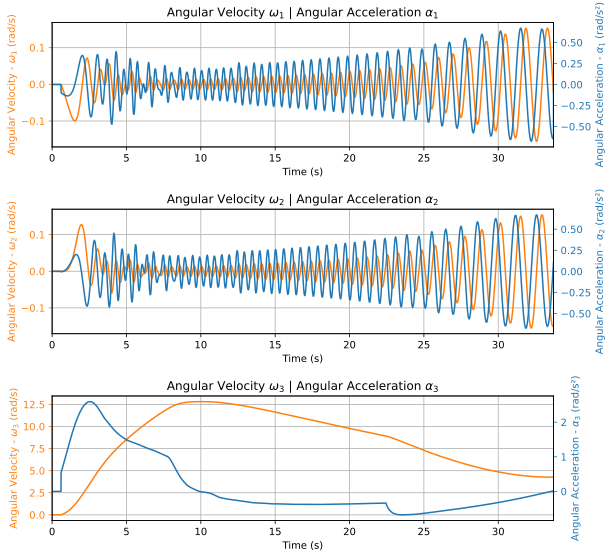



Aerodynamic Forces Plots



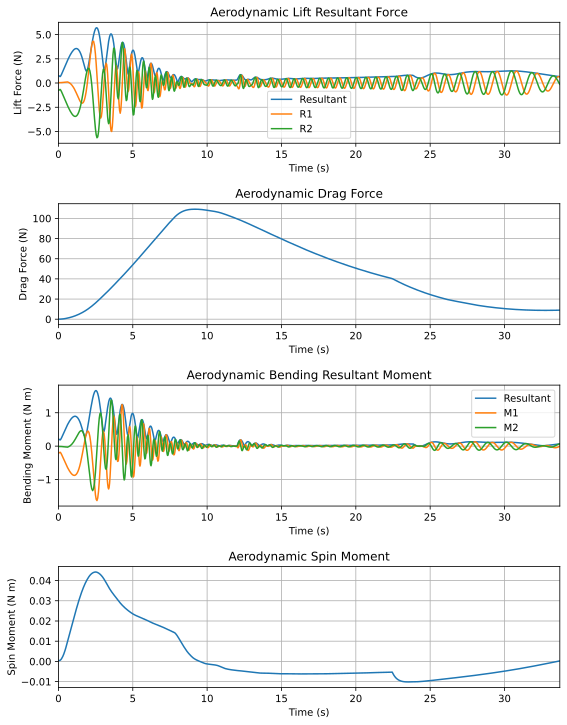



Rail Buttons Bending Moments Plots

Rail button height not defined. Skipping bending moment plots.


Rail Buttons Forces Plots



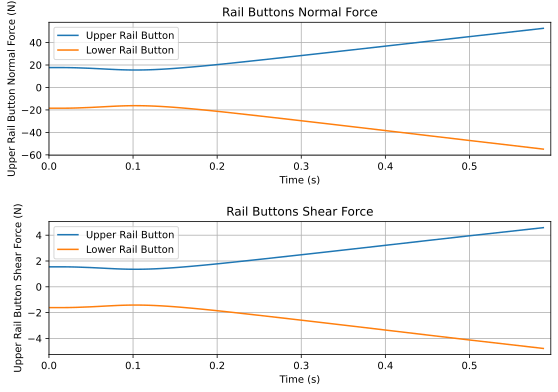



Trajectory Energy Plots



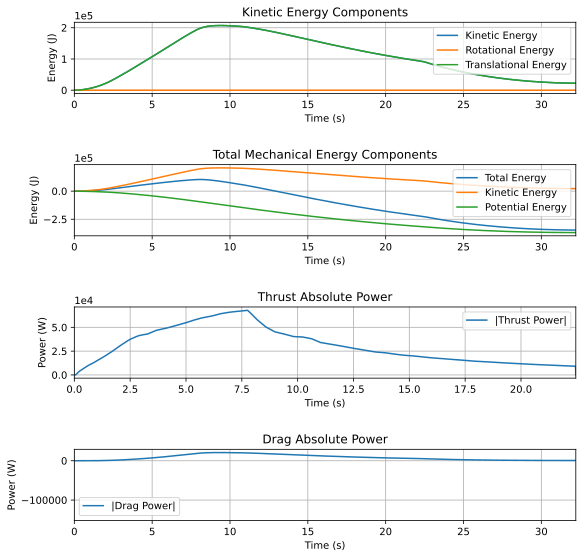



Trajectory Fluid Mechanics Plots



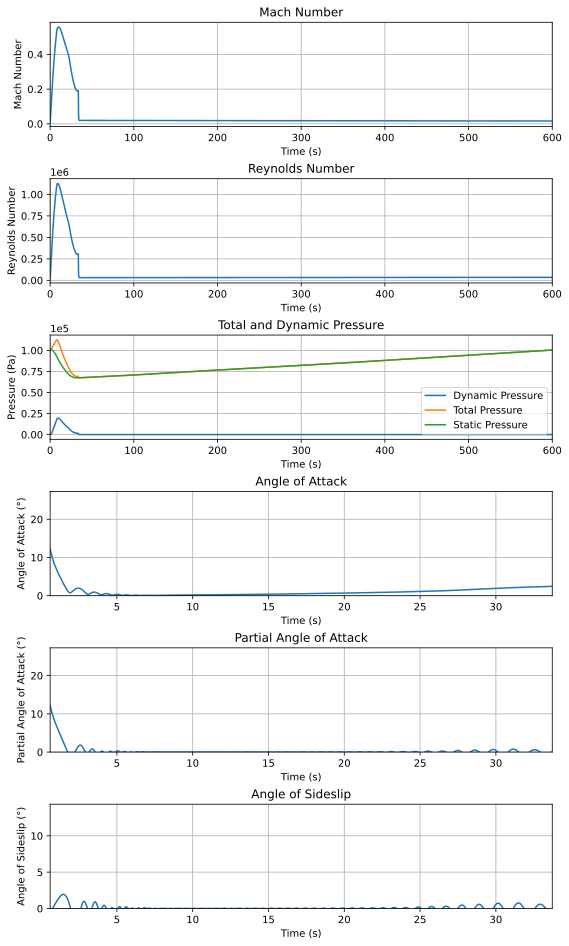



Trajectory Stability and Control Plots



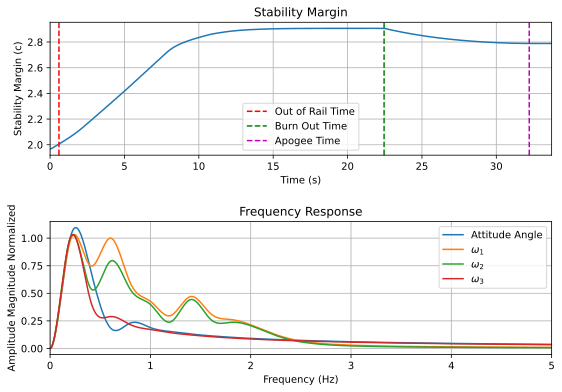



Rocket and Parachute Pressure Plots



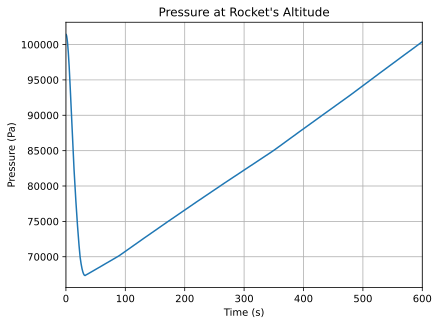


Parachute:  Main


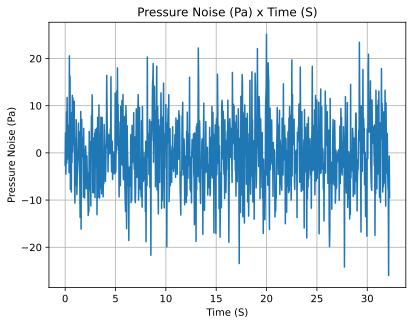

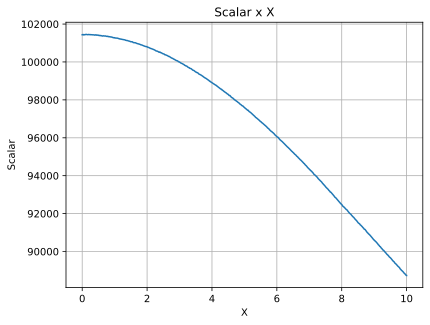

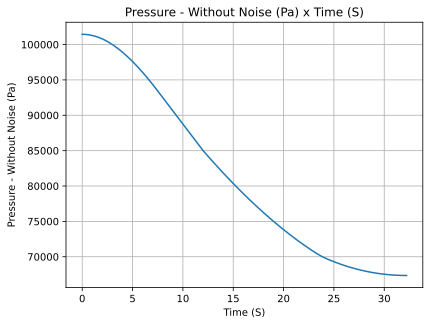

In [21]:
flight.all_info()